In [1]:
import numpy as np
from scipy.integrate import solve_ivp as sp_solve_ivp
from scipy.integrate import odeint
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from typing import List
device = 'cpu'
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from sklearn.preprocessing import MinMaxScaler
from ftnode.utils import set_global_seed
from ftnode.node import (
    FTNODE, FeluSigmoidMLP, GeluSigmoidMLP,GeluSigmoidMLPfeaturized)

import torchode

seed = 1234
set_global_seed(seed)

random_state = 67

[Seed] Deterministic mode enabled (may reduce speed).


In [2]:
def hysteresis_ode(t,x,lam):
    return lam+x-x**3

n_lam = 51
n_traj = 51
lams = np.linspace(-1,1,n_lam)
xs = np.linspace(-2,2,n_traj)


t_max = 0.25
n_colloc = 101


Xs = []
Us = []
t = np.linspace(0,t_max,n_colloc)
for lami in tqdm(lams):
    for x0 in xs:
        sol = sp_solve_ivp(
            hysteresis_ode,
            t_span = [0,t_max],
            y0 = np.array(x0).reshape(-1),
            t_eval = np.linspace(0,t_max,n_colloc),
            args = (lami,)
        )

        Xs.append(sol.y.T)
        Us.append([lami])
Xs = np.array(Xs)
Us = np.array(Us)

scaler = MinMaxScaler(feature_range=(-1,1))
scaler.fit(Xs.reshape(-1,1).reshape(-1,1))

  0%|          | 0/51 [00:00<?, ?it/s]

,feature_range,"(-1, ...)"
,copy,True
,clip,False


In [3]:
model_path = "../best_model-20-20-20.pth"

f = FeluSigmoidMLP(
    dims=[1,20,20,20, 1],
    activation=nn.SiLU(),
    lower_bound=-5,
    upper_bound=-0.1,
    init_type=None
)


g = GeluSigmoidMLPfeaturized(
    dims=[6, 20,20,20, 1],
    activation=nn.SiLU(),
    lower_bound=-2,
    upper_bound=2,
    freq_sample_step=1,
    feat_lower_bound=-1.5,
    feat_upper_bound=1.5,
    init_type=None
)

model = FTNODE(f, g).to(device)
model.load_state_dict(torch.load(model_path))
model.eval() #

f = model.f
g = model.g

f.eval()
g.eval()

GeluSigmoidMLPfeaturized(
  (activation): SiLU()
  (network): MLP(
    (activation): SiLU()
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=20, bias=True)
      (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
      (3): Linear(in_features=20, out_features=1, bias=True)
    )
  )
)

In [4]:
def f_true(x):
    return -x**2

def g_true(x,lam):
    return (1/x)*(lam/x+1)

In [5]:
x_lin = np.linspace(-2,2,101)
lam_lin = np.linspace(-1,1,101)

X, L = np.meshgrid(x_lin, lam_lin)

# True g
with np.errstate(divide='ignore', invalid='ignore'):
    Z = g_true(X,L)

Z = np.nan_to_num(Z, nan=0, posinf=5, neginf=-5)
Z_clipped = np.clip(Z,-5,5)

# Node g
X_torch_scaled = torch.tensor(scaler.transform(X.reshape(-1,1)),dtype=torch.float32)
L_torch = torch.tensor(L.reshape(-1,1),dtype=torch.float32)

with torch.no_grad():
    Z_node = g(X_torch_scaled, L_torch)

Z_node_unscaled = scaler.inverse_transform(Z_node).reshape(X.shape)

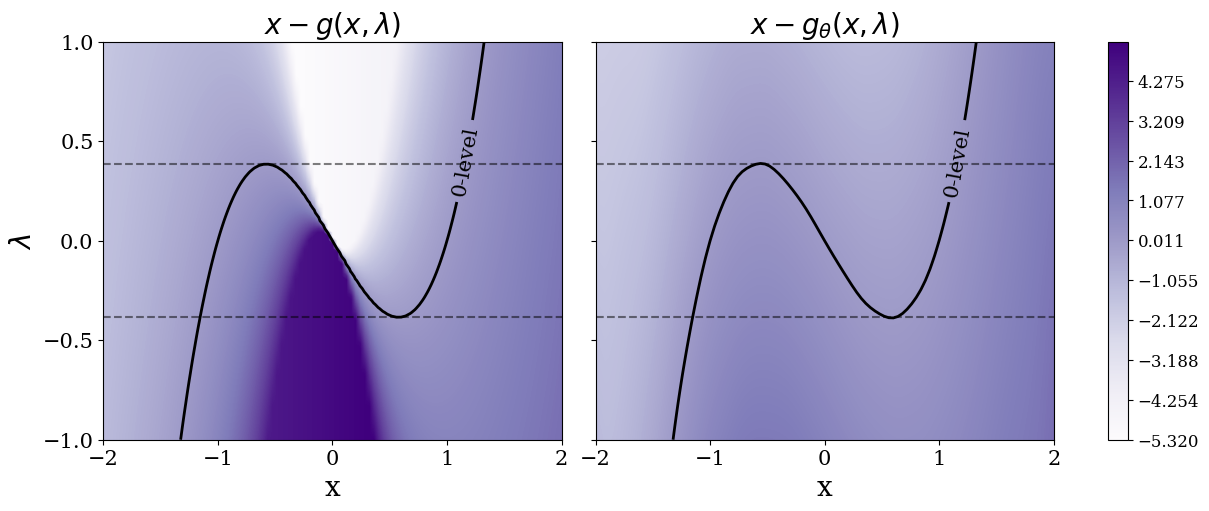

In [6]:

data_true = X - Z_clipped
data_node = X - Z_node_unscaled


v_min = np.min([data_true.min(), data_node.min()])
v_max = np.max([data_true.max(), data_node.max()])
common_levels = np.linspace(v_min, v_max, 500) 

lam_bounds = [-np.sqrt(4/27), np.sqrt(4/27)]


fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, constrained_layout=True)


ax = axs[0]

contour1 = ax.contourf(X, L, data_true, levels=common_levels, cmap='Purples', vmin=v_min, vmax=v_max)


zero_line = ax.contour(X, L, data_true, levels=[0], colors='black', linewidths=2)
ax.clabel(zero_line, fmt={0: '0-level'}, fontsize=15)

for lb in lam_bounds:
    ax.axhline(lb, color='black', linestyle='--', linewidth=1.5, alpha=0.5)

ax.set_xlabel('x',size=20)
ax.set_ylabel(r'$\lambda$',size=20)
ax.set_title(r'$x-g(x, \lambda)$',size=20)


ax = axs[1]

contour2 = ax.contourf(X, L, data_node, levels=common_levels, cmap='Purples', vmin=v_min, vmax=v_max)


zero_line = ax.contour(X, L, data_node, levels=[0], colors='black', linewidths=2)
ax.clabel(zero_line, fmt={0: '0-level'}, fontsize=15)

for lb in lam_bounds:
    ax.axhline(lb, color='black', linestyle='--', linewidth=1.5, alpha=0.5)

ax.set_xlabel('x',size=20)

ax.set_title(r'$x-g_{\theta}(x, \lambda)$',size=20)


cbar = fig.colorbar(contour2, ax=axs)
cbar.ax.tick_params(labelsize=12) 
for ax in axs:
    ax.tick_params(axis='both', which='major',labelsize=15)
    ax.set_yticks([-1,-0.5,0,0.5,1])

# plt.savefig("zero_set.pdf")
plt.show()

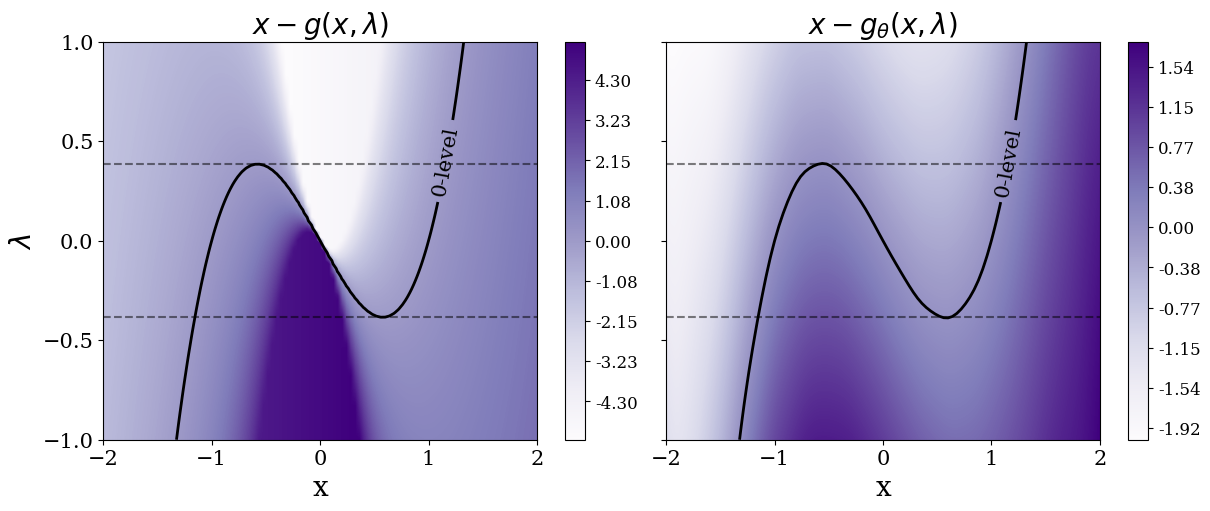

In [9]:

data_true = X - Z_clipped
data_node = X - Z_node_unscaled

v_min = np.min([data_true.min(), data_node.min()])
v_max = np.max([data_true.max(), data_node.max()])
common_levels = np.linspace(v_min, v_max, 500) 
common_levels = 500

lam_bounds = [-np.sqrt(4/27), np.sqrt(4/27)]


fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, constrained_layout=True)


ax = axs[0]

contour1 = ax.contourf(X, L, data_true, levels=common_levels, cmap='Purples',)


zero_line = ax.contour(X, L, data_true, levels=[0], colors='black', linewidths=2)
ax.clabel(zero_line, fmt={0: '0-level'}, fontsize=15)

for lb in lam_bounds:
    ax.axhline(lb, color='black', linestyle='--', linewidth=1.5, alpha=0.5)

ax.set_xlabel('x',size=20)
ax.set_ylabel(r'$\lambda$',size=20)
ax.set_title(r'$x-g(x, \lambda)$',size=20)


ax = axs[1]

contour2 = ax.contourf(X, L, data_node, levels=common_levels, cmap='Purples')

zero_line = ax.contour(X, L, data_node, levels=[0], colors='black', linewidths=2)
ax.clabel(zero_line, fmt={0: '0-level'}, fontsize=15)

for lb in lam_bounds:
    ax.axhline(lb, color='black', linestyle='--', linewidth=1.5, alpha=0.5)

ax.set_xlabel('x',size=20)
ax.set_title(r'$x-g_{\theta}(x, \lambda)$',size=20)


cbar1 = fig.colorbar(contour1, ax=axs[0])
cbar1.ax.tick_params(labelsize=12)
cbar1.formatter = plt.FormatStrFormatter('%.2f')
cbar1.update_ticks()

cbar2 = fig.colorbar(contour2, ax=axs[1])
cbar2.ax.tick_params(labelsize=12)
cbar2.formatter = plt.FormatStrFormatter('%.2f')
cbar2.update_ticks()

for ax in axs:
    ax.tick_params(axis='both', which='major',labelsize=15)
    ax.set_yticks([-1,-0.5,0,0.5,1])

plt.savefig("hysteresis_zero_set.png")
plt.show()
